# Testing Model, Inference & Crop Image

## 1. Testing YOLO26n after training

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
import sys

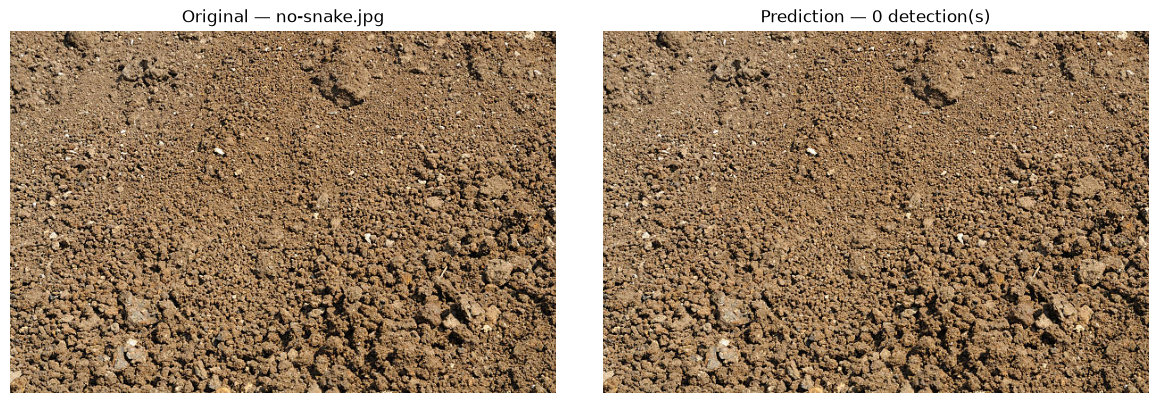

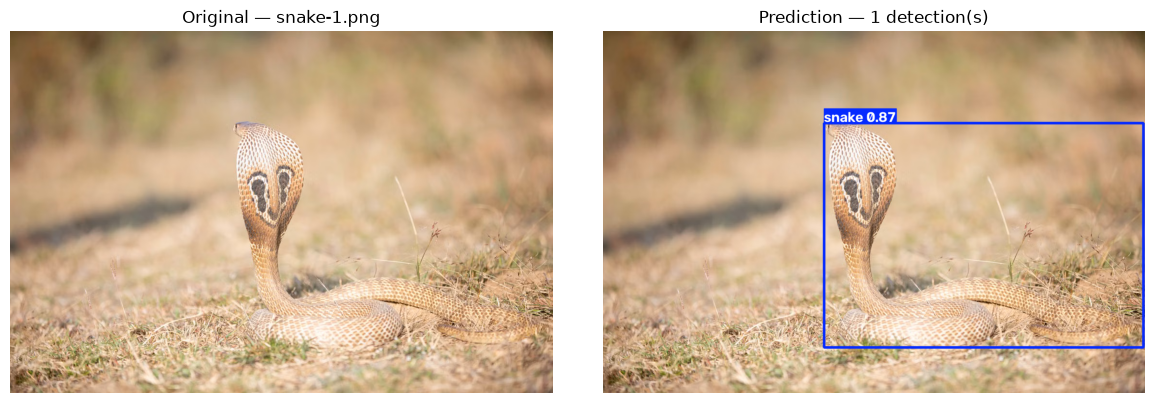

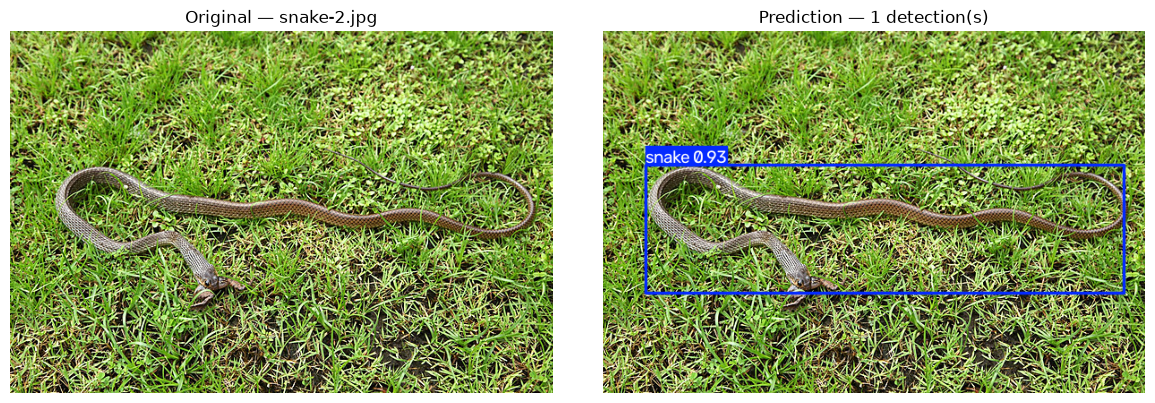

In [2]:
MODEL_PATH = Path("../models/detection/yolo26n_best.pt")
IMAGE_DIR = Path("../data/samples/detection")

model = YOLO(MODEL_PATH)

image_paths = sorted([
    path for path in IMAGE_DIR.iterdir()
    if path.suffix.lower() in {".jpg", ".jpeg", ".png"}
])

results = model.predict(image_paths, imgsz=640, conf=0.48, verbose=False)

for image_path, result in zip(image_paths, results):
    original = Image.open(image_path).convert("RGB")
    annotated = result.plot()[..., ::-1]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(original)
    axes[0].set_title(f"Original — {image_path.name}")
    axes[0].axis("off")

    axes[1].imshow(annotated)
    axes[1].set_title(f"Prediction — {len(result.boxes)} detection(s)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

In [3]:
for image_path, result in zip(image_paths, results):
    confidences = [round(box.conf.item(), 3) for box in result.boxes]

    print(
        f"{image_path.name} | "
        f"detections: {len(result.boxes)} | "
        f"confidence: {confidences} | "
        f"inference: {result.speed['inference']:.2f} ms"
    )

no-snake.jpg | detections: 0 | confidence: [] | inference: 78.64 ms
snake-1.png | detections: 1 | confidence: [0.869] | inference: 78.64 ms
snake-2.jpg | detections: 1 | confidence: [0.932] | inference: 78.64 ms


## 2. Testing Inference & Crop Image

In [4]:
PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from ml.detection.inference import SnakeDetector

MODEL_PATH = PROJECT_ROOT / "models/detection/yolo26n_best.pt"

detector = SnakeDetector(MODEL_PATH)

In [5]:
IMAGE_PATH = PROJECT_ROOT / "data/samples/detection/snake-1.png"

detections = detector.predict(IMAGE_PATH)

print(f"Detections: {len(detections)}")

for detection in detections:
    print(
        f"BBox: {detection['bbox']} | "
        f"Confidence: {detection['confidence']:.3f}"
    )

Detections: 1
BBox: [459, 190, 1118, 657] | Confidence: 0.875


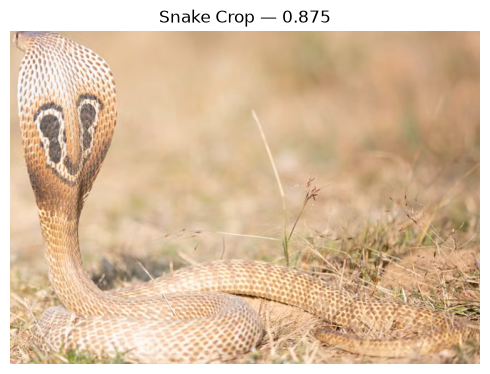

In [6]:
fig, axes = plt.subplots(1, len(detections), figsize=(5 * len(detections), 4))

if len(detections) == 1:
    axes = [axes]

for i, detection in enumerate(detections):
    axes[i].imshow(detection["crop"])
    axes[i].set_title(f"Snake Crop — {detection['confidence']:.3f}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [7]:
OUTPUT_DIR = Path("../outputs/detection")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for image_path in image_paths:
    detections = detector.predict(image_path)

    for i, detection in enumerate(detections, 1):
        crop_path = OUTPUT_DIR / f"{image_path.stem}_crop_{i}.jpg"
        detection["crop"].save(crop_path)

        print(
            f"{crop_path.name} | "
            f"confidence: {detection['confidence']:.3f}"
        )

snake-1_crop_1.jpg | confidence: 0.875
snake-2_crop_1.jpg | confidence: 0.936
